In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor


In [12]:
df=pd.read_csv('data\stud.csv')


show top 5 records

In [13]:
df.head(5)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [14]:
df.tail(5)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [16]:
X=df.drop('math_score',axis=1)
y=df['math_score']

In [18]:
X.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88


In [19]:
y.head(2)

0    72
1    69
Name: math_score, dtype: int64

In [20]:
type(y)

pandas.Series

In [21]:
for i in df.columns:
    if df[i].dtypes=='str':
        print(i)

gender
race_ethnicity
parental_level_of_education
lunch
test_preparation_course


In [25]:
categorical_cols=[i for i in X.columns if df[i].dtypes=='str']
numerical_cols=[i for i in X.columns if df[i].dtypes!='str']

In [28]:
print(numerical_cols)
print(categorical_cols)

['reading_score', 'writing_score']
['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder

scaler=StandardScaler()
ohe=OneHotEncoder()

preprocessor=ColumnTransformer(
    [
        ("OneHotEncoder",ohe,categorical_cols),
        ("StandardScaler",scaler,numerical_cols)
    ]
)

In [30]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OneHotEncoder', ...), ('StandardScaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``f

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [34]:
X_train.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
29,female,group D,master's degree,standard,none,70,75
535,female,group C,bachelor's degree,free/reduced,completed,83,83
695,female,group D,some college,free/reduced,none,89,86
557,male,group C,master's degree,free/reduced,none,67,66
836,male,group E,high school,standard,none,64,57


In [36]:
X_train=preprocessor.fit_transform(X_train)
X_test=preprocessor.transform(X_test)

In [37]:
X_train

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.03079054,  0.43405338],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.9302895 ,  0.96470125],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.34544287,  1.1636942 ],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
        -0.52274728, -1.02522827],
       [ 0.        ,  1.        ,  0.        , ...,  0.        ,
        -1.49143847, -1.02522827],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.48382733,  1.36268716]], shape=(800, 19))

In [43]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42),
    "KNeighborsRegressor": KNeighborsRegressor(),
    "AdaBoostRegressor": AdaBoostRegressor(random_state=42),
    "RandomForestRegressor": RandomForestRegressor(random_state=42),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42)
}

In [44]:
models.keys()

dict_keys(['LinearRegression', 'Ridge', 'Lasso', 'KNeighborsRegressor', 'AdaBoostRegressor', 'RandomForestRegressor', 'GradientBoostingRegressor'])

In [46]:
models.values()

dict_values([LinearRegression(), Ridge(random_state=42), Lasso(random_state=42), KNeighborsRegressor(), AdaBoostRegressor(random_state=42), RandomForestRegressor(random_state=42), GradientBoostingRegressor(random_state=42)])

In [47]:
models.items()

dict_items([('LinearRegression', LinearRegression()), ('Ridge', Ridge(random_state=42)), ('Lasso', Lasso(random_state=42)), ('KNeighborsRegressor', KNeighborsRegressor()), ('AdaBoostRegressor', AdaBoostRegressor(random_state=42)), ('RandomForestRegressor', RandomForestRegressor(random_state=42)), ('GradientBoostingRegressor', GradientBoostingRegressor(random_state=42))])

In [50]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [61]:
scores = {}

for name, model in models.items():

    print(f"{name} training\n")

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print("Training Set Performance")
    print("mean squared error:", mean_squared_error(y_train, y_train_pred))
    print("mean absolute error:", mean_absolute_error(y_train, y_train_pred))
    print("R2 score:", r2_score(y_train, y_train_pred))

    print()

    print("Test Set Performance")
    print("mean squared error:", mean_squared_error(y_test, y_test_pred))
    print("mean absolute error:", mean_absolute_error(y_test, y_test_pred))
    print("R2 score:", r2_score(y_test, y_test_pred))

    scores[name] = r2_score(y_test, y_test_pred)

    print("--"*20)
    print()

LinearRegression training

Training Set Performance
mean squared error: 28.33487038064859
mean absolute error: 4.26671184607196
R2 score: 0.8743172040139593

Test Set Performance
mean squared error: 29.095169866715526
mean absolute error: 4.214763142474852
R2 score: 0.8804332983749563
----------------------------------------

Ridge training

Training Set Performance
mean squared error: 28.337741791088877
mean absolute error: 4.265005112727169
R2 score: 0.8743044675204547

Test Set Performance
mean squared error: 29.05660162669484
mean absolute error: 4.211112826071165
R2 score: 0.8805917946912825
----------------------------------------

Lasso training

Training Set Performance
mean squared error: 43.46111315450668
mean absolute error: 5.205261564799371
R2 score: 0.8072228972801443

Test Set Performance
mean squared error: 42.475807020718484
mean absolute error: 5.155719544015372
R2 score: 0.8254455235149138
----------------------------------------

KNeighborsRegressor training

Traini

In [62]:
scores

{'LinearRegression': 0.8804332983749563,
 'Ridge': 0.8805917946912825,
 'Lasso': 0.8254455235149138,
 'KNeighborsRegressor': 0.7859441830800236,
 'AdaBoostRegressor': 0.8532233151557893,
 'RandomForestRegressor': 0.8512822812106478,
 'GradientBoostingRegressor': 0.8721981770188983}

In [65]:
scores_df=pd.DataFrame(list(scores.items()),columns=['model_name','r2_score'])
scores_df.sort_values(by='r2_score',ascending=False)

,model_name,r2_score
1,Ridge,0.880592
0,LinearRegression,0.880433
6,GradientBoostingRegressor,0.872198
4,AdaBoostRegressor,0.853223
5,RandomForestRegressor,0.851282
2,Lasso,0.825446
3,KNeighborsRegressor,0.785944


In [71]:
model=LinearRegression(fit_intercept=True)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

r2=r2_score(y_test,y_pred)*100
print(f"Linear Regression model accuracy: {r2:.2f}")

Linear Regression model accuracy: 88.04


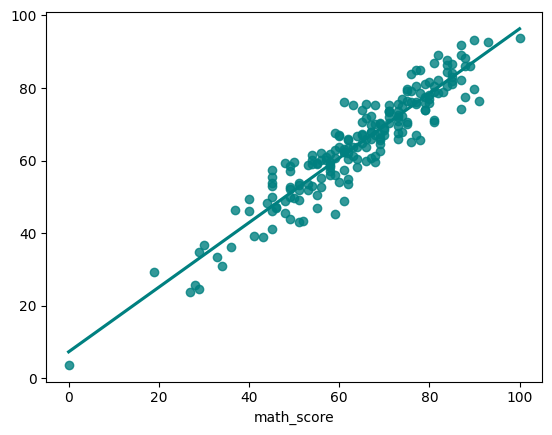

In [75]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='teal')
plt.show()

difference between predicted and actual val

In [76]:
pd.DataFrame({'actual_value':y_test,'predicted_Value':y_pred,'difference':y_test-y_pred})

,actual_value,predicted_Value,difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287


In [15]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
